In [1]:
import os
from pathlib import Path
from ures.files import filter_files
from perf_estimator.estimator import Estimator
from perf_estimator.dataset import image_dataset
from experiments.snapshot import SnapshotAnalyser
from perf_estimator.profiler import ProfilerDataProcessing
from ures.string import format_memory


In [2]:
# Setup Basic Global Variables
root_dir = Path("/Users/jiaboshi/Documents/101-Data/002-xMem-LLM")
# root_dir = Path("/home/glaswigian/Documents/200-ResearchData/100-researchData/002-xMem-LLM/")
pytorch_dir = root_dir / "001-PyTorch"
huggingface_dir = root_dir / "002-HuggingFace"

pytorch_dir_name_format = "recurrence-{}-SGD-{}-1"
huggingface_dir_name_format_xmem = "{}-{}-xMem"
huggingface_dir_name_format_llm = "{}-{}-LLM"
huggingface_dir_name_format_cuda = "{}-{}-CUDA"

In [3]:
model = "VGG16"
batch_size = "170"
max_gpu_memory = 8

In [14]:
def get_xmem_memory(profiler_file, batch, max_in_gb):
    estimator = Estimator(
        dataloader=image_dataset(batch=int(batch)),
        profiler_file=profiler_file,
        max_gpu_memory_in_gb=max_in_gb
    )
    my_result, _ = estimator.estimate()
    return max(my_result._trace.max_segment_changes), estimator


def get_ground_value_from_snapshot(snapshot_file: str) -> dict:
    _snapshot = SnapshotAnalyser(snapshot_file)
    return _snapshot.gpu_and_segment_in_same_time_length()

import re

def extract_bytes(mem_list):
    """
    从每个内存条目中提取 Bytes 数值，返回排序后的数值列表。
    假设每个内存条目是一个字符串，格式中包含 "Bytes:<数字>"
    """
    bytes_values = []
    pattern = re.compile(r'Bytes:(\d+)')
    for item in mem_list:
        # 将 item 转换为字符串以防万一
        text = str(item)
        match = pattern.search(text)
        if match:
            bytes_values.append(int(match.group(1)))
    return sorted(bytes_values)

def compare_memory_bytes(list1, list2, debug=False):
    """
    比较两个列表中各模块的 forward_memory 和 backward_memory 中的 bytes 数值是否一致
    """
    # 构造成字典，以模块名称为 key
    dict1 = {entry['name']: entry for entry in list1}
    dict2 = {entry['name']: entry for entry in list2}
    forward_matched = True
    backwrd_matched = True

    # 得到所有模块名称
    all_names = set(dict1.keys()).union(dict2.keys())

    for name in all_names:
        entry1 = dict1.get(name)
        entry2 = dict2.get(name)

        if entry1 is None:
            print(f"模块 {name} 仅存在于第二个列表中。")
            continue
        if entry2 is None:
            print(f"模块 {name} 仅存在于第一个列表中。")
            continue

        # 分别提取 forward_memory 和 backward_memory 中的 bytes 数值
        forward_bytes1 = extract_bytes(entry1.get('forward_memory', []))
        forward_bytes2 = extract_bytes(entry2.get('forward_memory', []))
        backward_bytes1 = extract_bytes(entry1.get('backward_memory', []))
        backward_bytes2 = extract_bytes(entry2.get('backward_memory', []))

        if forward_bytes1 == forward_bytes2:
            if debug:
                print(f"{name}: forward_memory 的 bytes 匹配")
        else:
            forward_matched = False
            if debug:
                print(f"{name}: forward_memory 的 bytes 不匹配")
                print(f"  List1: {forward_bytes1}")
                print(f"  List2: {forward_bytes2}")

        if backward_bytes1 == backward_bytes2:
            if debug:
                print(f"{name}: backward_memory 的 bytes 匹配")
        else:
            backwrd_matched = False
            if debug:
                print(f"{name}: backward_memory 的 bytes 不匹配")
                print(f"  List1: {backward_bytes1}")
                print(f"  List2: {backward_bytes2}")

    return forward_matched, backwrd_matched


In [15]:
from typing import Union
def get_all_memory_information(model_name: str, batch: Union[str, int]) -> dict:
    batch = str(batch)
    # Get PyTorch Data
    torch_data_dir = pytorch_dir.joinpath(pytorch_dir_name_format.format(model_name, batch))
    all_torch_dirs = os.listdir(torch_data_dir)
    all_torch_dirs = [torch_data_dir.joinpath(d) for d in all_torch_dirs if str(d).startswith(".") is False]
    dirs_sorted = sorted(all_torch_dirs, key=lambda d: d.stat().st_ctime)
    torch_snapshot_file = filter_files(".pickle", dirs_sorted[0], fuzz=True)[-1]
    torch_profiler_file = filter_files(".pt.trace.json", dirs_sorted[0], fuzz=True)[-1]

    # Get HuggingFace Data
    huggingface_dir_xmem = huggingface_dir.joinpath(huggingface_dir_name_format_xmem.format(model_name, batch))
    huggingface_dir_cuda = huggingface_dir.joinpath(huggingface_dir_name_format_cuda.format(model_name, batch))
    huggingface_dir_llm = huggingface_dir.joinpath(huggingface_dir_name_format_llm.format(model_name, batch))
    huggingface_profiler_file_xmem = filter_files(".pt.trace.json", huggingface_dir_xmem, fuzz=True)[-1]
    huggingface_profiler_file_llm = filter_files(".pt.trace.json", huggingface_dir_llm, fuzz=True)[-1]
    huggingface_snapshot_file_xmem = filter_files(".pickle", huggingface_dir_cuda, fuzz=True)[-1]

    # Estimate memory
    huggingface_memory_llm, huggingface_estimator = get_xmem_memory(
        profiler_file=huggingface_profiler_file_llm,
        batch=batch_size,
        max_in_gb=max_gpu_memory
    )
    huggingface_snapshot_memory_xmen = max(get_ground_value_from_snapshot(huggingface_snapshot_file_xmem)['seg'])
    huggingface_memory_diff = huggingface_memory_llm - huggingface_snapshot_memory_xmen

    paper_memory_result, paper_estimator = get_xmem_memory(
        profiler_file=torch_profiler_file,
        batch=batch_size,
        max_in_gb=max_gpu_memory
    )
    paper_snapshot_result = max(get_ground_value_from_snapshot(torch_snapshot_file)['seg'])
    paper_memory_diff = paper_memory_result - paper_snapshot_result

    forward_matched, backward_matched = compare_memory_bytes(
        paper_estimator.profiler.get_iteration(1).layer_summary(),
        huggingface_estimator.profiler.get_iteration(1).layer_summary()
    )

    return {
        "torch": {
            "est": paper_memory_result,
            "ground": paper_snapshot_result,
            "error": round((abs(paper_memory_result - paper_snapshot_result)/paper_snapshot_result)*100, 2),
            "diff": paper_memory_diff
        },
        "huggingface": {
            "est": huggingface_memory_llm,
            "ground": huggingface_snapshot_memory_xmen,
            "error": round((abs(huggingface_memory_llm - huggingface_snapshot_memory_xmen)/huggingface_snapshot_memory_xmen)*100, 2),
            "diff": huggingface_memory_diff
        },
        "compare": {
            "forward": forward_matched,
            "backward": backward_matched,
            "groud_diff": paper_snapshot_result - huggingface_snapshot_memory_xmen
        }
    }


In [16]:
models = ["ConvNeXtTiny", "ResNet50", "VGG16"]
batch = range(10, 570, 40)

In [ ]:
result_list = []
for m in models:
    for b in batch:
        _r = get_all_memory_information(m, b)
        _r.update({
            "model": m,
            "batch": b
        })
        result_list.append(_r)

In [8]:
import pandas as pd
df = pd.json_normalize(result_list)

In [9]:
df

,model,batch,torch.est,torch.ground,torch.error,torch.diff,huggingface.est,huggingface.ground,huggingface.error,huggingface.diff,compare.forward,compare.backward,compare.groud_diff
0,ConvNeXtTiny,10,369098752,375390208,1.68,-6291456,260046848,262144000,0.80,-2097152,True,True,113246208
1,ConvNeXtTiny,50,994050048,723517440,37.39,270532608,882900992,958398464,7.88,-75497472,True,True,-234881024
2,ConvNeXtTiny,90,1614807040,1654652928,2.41,-39845888,1495269376,1629487104,8.24,-134217728,True,True,25165824
3,ConvNeXtTiny,130,2210398208,2449473536,9.76,-239075328,2097152000,2281701376,8.09,-184549376,True,True,167772160
4,ConvNeXtTiny,170,2824863744,2774532096,1.81,50331648,2713714688,2925527040,7.24,-211812352,True,True,-150994944
5,ConvNeXtTiny,210,3468689408,2774532096,25.02,694157312,3334471680,3590324224,7.13,-255852544,True,True,-815792128
6,ConvNeXtTiny,250,4106223616,4678746112,12.24,-572522496,3995074560,4280287232,6.66,-285212672,True,True,398458880
7,ConvNeXtTiny,290,4720689152,4615831552,2.27,104857600,4594860032,4945084416,7.08,-350224384,True,True,-329252864
8,ConvNeXtTiny,330,5368709120,5249171456,2.28,119537664,5232394240,5599395840,6.55,-367001600,True,True,-350224384
9,ConvNeXtTiny,370,5911871488,5771362304,2.43,140509184,5781848064,6199181312,6.73,-417333248,True,True,-427819008



# Analysis of Shopshot Data between PyTorch and HuggingFace


In [4]:
model_name = model
batch = batch_size
torch_data_dir = pytorch_dir.joinpath(pytorch_dir_name_format.format(model_name, batch))
all_torch_dirs = os.listdir(torch_data_dir)
all_torch_dirs = [torch_data_dir.joinpath(d) for d in all_torch_dirs if str(d).startswith(".") is False and str(d).startswith("@") is False]
dirs_sorted = sorted(all_torch_dirs, key=lambda d: d.stat().st_ctime)

In [5]:
torch_snapshot_file = Path(filter_files(".pickle", dirs_sorted[0], fuzz=True)[0])
torch_profiler_file = Path(filter_files(".pt.trace.json", dirs_sorted[0], fuzz=True)[-1])


In [6]:
# Get HuggingFace Data
huggingface_dir_xmem = huggingface_dir.joinpath(huggingface_dir_name_format_xmem.format(model_name, batch))
huggingface_dir_cuda = huggingface_dir.joinpath(huggingface_dir_name_format_cuda.format(model_name, batch))
huggingface_dir_llm = huggingface_dir.joinpath(huggingface_dir_name_format_llm.format(model_name, batch))
huggingface_profiler_file_xmem = filter_files(".pt.trace.json", huggingface_dir_xmem, fuzz=True)[-1]
huggingface_profiler_file_llm = filter_files(".pt.trace.json", huggingface_dir_llm, fuzz=True)[-1]
huggingface_snapshot_file_xmem = Path(filter_files(".pickle", huggingface_dir_cuda, fuzz=True)[-1])

torch_snapshot_file

PosixPath('/Users/jiaboshi/Documents/101-Data/002-xMem-LLM/001-PyTorch/recurrence-VGG16-SGD-170-1/20241126-015141-d180/results/snapshot/snapshot_result-1732585963.pickle')

In [7]:
torch_snapshot = SnapshotAnalyser(torch_snapshot_file)
hugging_snapshot = SnapshotAnalyser(huggingface_snapshot_file_xmem)

In [8]:
xx = hugging_snapshot.group_by_file('/home/glaswigian/miniconda3/envs/Huggingface/lib/python3.12/site-packages/transformers/trainer.py')
print(xx.keys())

dict_keys(['5153/get_batch_samples', '5160/get_batch_samples', '3731/compute_loss', '3710/training_step', '3712/training_step', '2536/_inner_training_loop', '2545/_inner_training_loop', '2566/_inner_training_loop', '5168/get_batch_samples', '2594/_inner_training_loop'])


In [9]:
torch_profiler = ProfilerDataProcessing(torch_profiler_file)

In [10]:
huggingface_profiler = ProfilerDataProcessing(huggingface_profiler_file_llm)
huggingface_profiler_file_llm

'/Users/jiaboshi/Documents/101-Data/002-xMem-LLM/002-HuggingFace/VGG16-170-LLM/results/callback/Profiler/Glaswigian-Researcher_123964.1739486916203614949.pt.trace.json'

In [17]:
layer_in_torch = torch_profiler.get_iteration(2).layer_summary()
layer_in_hugging = huggingface_profiler.get_iteration(2).layer_summary()

In [18]:
_, torch_estimator = get_xmem_memory(torch_profiler_file, batch_size, max_gpu_memory)
_, hugging_estimator = get_xmem_memory(huggingface_profiler_file_llm, batch_size, max_gpu_memory)

In [19]:
training_memorys = torch_estimator.get_an_iteration_memory(iteration_index=2)
model_memory = torch_estimator.model_memory(iteration=2)
estimated_instance, estimated_result = torch_estimator.memory_estimate(training_memorys)
estimated_model_instance, estimated_model_result = torch_estimator.memory_estimate(model_memory)

print(f"Model Memory: {format_memory(estimated_model_result['memory']['segment'])}\n"
      f"Training Memory: {format_memory(estimated_result['memory']['segment'])}")


Model Memory: 534.00 MB
Training Memory: 3.28 GB


In [25]:
hugging_memory = hugging_estimator.get_an_iteration_memory(iteration_index=2, zero_grad=False)
hugging_model_memory = hugging_estimator.model_memory(iteration=2)
hugging_estimated_instance, hugging_estiamted_result = hugging_estimator.memory_estimate(hugging_memory)
hugging_estimated_memory_instance, hugging_model_memory_result = hugging_estimator.memory_estimate(hugging_model_memory)

print(f"Model Memory: {format_memory(hugging_model_memory_result['memory']['segment'])}\n"
        f"Training Memory: {format_memory(hugging_estiamted_result['memory']['segment'])}")

Model Memory: 0 B
Training Memory: 3.28 GB


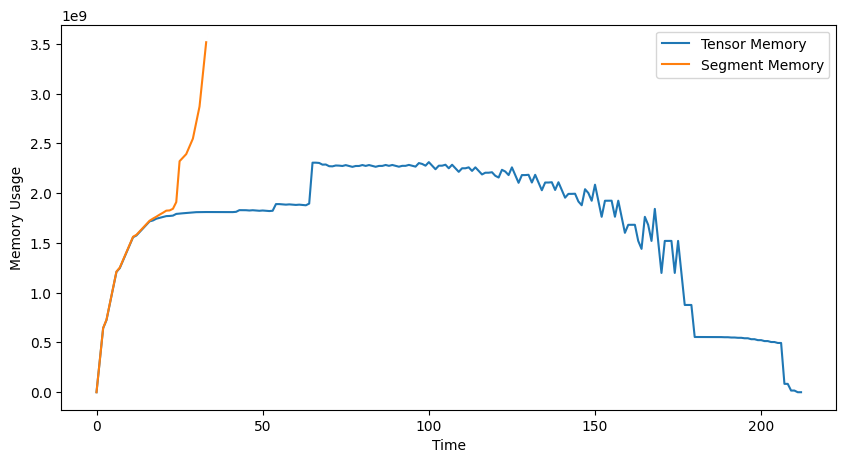

In [26]:
hugging_estimated_instance.plot_memory_change()

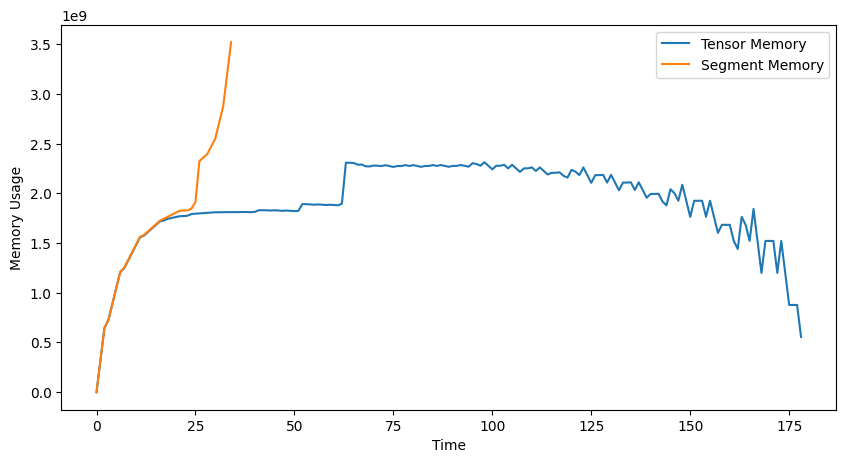

In [22]:
estimated_instance.plot_memory_change()

In [23]:
hugging_memory

[Memory(forward|133479018790976|free): Bytes:321873920, Start:3854551698484.812, End:3854554224904.184, Comments: Conv2d_0,
 Memory(forward|133479341752384|free): Bytes:321873920, Start:3854551834437.581, End:3854553910514.251, Comments: Conv2d_1,
 Memory(forward|133478937002048|free): Bytes:80468480, Start:3854551871901.679, End:3854553838276.946, Comments: MaxPool2d_0,
 Memory(forward|133478775521344|free): Bytes:160936960, Start:3854551871908.323, End:3854553870098.036, Comments: MaxPool2d_0,
 Memory(forward|133478370771008|free): Bytes:160936960, Start:3854551933987.895, End:3854553716752.285, Comments: Conv2d_2,
 Memory(forward|133478614040640|free): Bytes:160936960, Start:3854552031213.292, End:3854553496862.587, Comments: Conv2d_3,
 Memory(forward|1176934400|free): Bytes:38384640, Start:3854552050060.39, End:3854553465573.623, Comments: MaxPool2d_1,
 Memory(forward|133478536446016|free): Bytes:76769280, Start:3854552050085.548, End:3854553479302.363, Comments: MaxPool2d_1,
 Memo

In [24]:
training_memorys

[Memory(forward|133569951301696|free): Bytes:321873920, Start:1732585917782908, End:1732585920382996, Comments: Conv2d_0,
 Memory(forward|133570274263104|free): Bytes:321873920, Start:1732585917918492, End:1732585920074427, Comments: Conv2d_1,
 Memory(forward|133569869512768|free): Bytes:80468480, Start:1732585917955478, End:1732585920004180, Comments: MaxPool2d_0,
 Memory(forward|133569708032064|free): Bytes:160936960, Start:1732585917955484, End:1732585920036420, Comments: MaxPool2d_0,
 Memory(forward|133569303281728|free): Bytes:160936960, Start:1732585918018394, End:1732585919877067, Comments: Conv2d_2,
 Memory(forward|133569546551360|free): Bytes:160936960, Start:1732585918117723, End:1732585919653419, Comments: Conv2d_3,
 Memory(forward|133570685304896|free): Bytes:38384640, Start:1732585918136500, End:1732585919613863, Comments: MaxPool2d_1,
 Memory(forward|133569468956736|free): Bytes:76769280, Start:1732585918136510, End:1732585919630750, Comments: MaxPool2d_1,
 Memory(forward